In [1]:
import pypsa

In [2]:
n = pypsa.Network()

n.add("Bus", "generation_bus")
n.add("Bus", "load_bus")

n.add("Generator", "coal plant", p_nom=300, bus="generation_bus", marginal_cost=3)
n.add("Generator", "gas plant", p_nom=400, bus="generation_bus", marginal_cost=4)

n.add("Load", "load", p_set=500, bus="load_bus")

n.add("Line", "line", bus0="generation_bus", bus1="load_bus", x=0.1, r=0.1, s_nom=1000)

In [18]:
n.optimize(solver_name="highs")

/var/folders/c3/657p__892k72qxh6r8fdkqsh0000gn/T/ipykernel_639/3144390136.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['generation_bus', 'load_bus'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3 primals, 8 duals
Objective: 1.70e+03
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p

Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-drauumc_ has 8 rows; 3 cols; 10 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [3e+00, 4e+00]
  Bound   [0e+00, 0e+00]
  RHS     [3e+02, 1e+03]
Presolving model
1 rows, 2 cols, 2 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-8); columns 0(-3); nonzeros 0(-10) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-drauumc_
Model status        : Optimal
Objective value     :  1.7000000000e+03
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


('ok', 'optimal')

In [4]:
n.model.to_file("simple.lp")

INFO:linopy.io: Writing time: 0.03s


PosixPath('simple.lp')

In [5]:
cn = pypsa.Network()


In [6]:
cn = pypsa.Network()

cn.set_snapshots(range(3))

cn.add("Bus", "gas_plant_bus")
cn.add("Bus", "coal_plant_bus")
cn.add("Bus", "load_bus")

cn.add("Generator", "coal plant", p_nom=300, bus="coal_plant_bus", marginal_cost=3)
cn.add("Generator", "gas plant", p_nom=400, bus="gas_plant_bus", marginal_cost=4)

cn.add("Load", "load", p_set=[500, 400, 700], bus="load_bus")

cn.add("Line", "gas_line", bus0="gas_plant_bus", bus1="load_bus", x=0.1, r=0.1, s_nom=1000)
cn.add("Line", "coal_line", bus0="coal_plant_bus", bus1="load_bus", x=0.1, r=0.1, s_nom=1000)

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x7016ec7710>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x7016ea5a90>},
 'flows': {}}

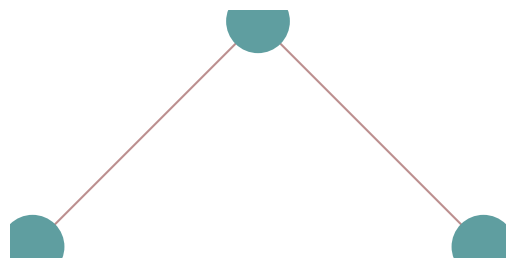

In [7]:
cn.plot()

In [8]:
cn.optimize(solver_name="highs")

/var/folders/c3/657p__892k72qxh6r8fdkqsh0000gn/T/ipykernel_639/3695655608.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  cn.optimize(solver_name="highs")
Index(['gas_plant_bus', 'coal_plant_bus', 'load_bus'], dtype='object', name='name')
Index(['gas_line', 'coal_line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12 primals, 33 duals
Objective: 5.50e+03
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-uppe

Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-_n2ck0ac has 33 rows; 12 cols; 42 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [3e+00, 4e+00]
  Bound   [0e+00, 0e+00]
  RHS     [3e+02, 1e+03]
Presolving model
0 rows, 0 cols, 0 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-33); columns 0(-12); nonzeros 0(-42) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-_n2ck0ac
Model status        : Optimal
Objective value     :  5.5000000000e+03
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


('ok', 'optimal')

In [9]:
cn.generators_t['p']

name,coal plant,gas plant
snapshot,,
0,300.0,200.0
1,300.0,100.0
2,300.0,400.0


In [10]:
cn.loads_t['p']

name,load
snapshot,
0,500.0
1,400.0
2,700.0


In [11]:
cnr = pypsa.Network()

cnr.set_snapshots(range(3))

cnr.add("Bus", "gas_plant_bus")
cnr.add("Bus", "coal_plant_bus")
cnr.add("Bus", "load_bus")

cnr.add("Generator", "coal plant", p_nom=300, bus="coal_plant_bus", marginal_cost=3)
cnr.add("Generator", "gas plant", p_nom=400, bus="gas_plant_bus", marginal_cost=4)
cnr.add("Generator", "solar plant", p_nom =200, p_max_pu=[0.0, 1, 0.0], bus="coal_plant_bus", marginal_cost=2)

cnr.add("Load", "load", p_set=[500, 400, 700], bus="load_bus")

cnr.add("Line", "gas_line", bus0="gas_plant_bus", bus1="load_bus", x=0.1, r=0.1, s_nom=1000)
cnr.add("Line", "coal_line", bus0="coal_plant_bus", bus1="load_bus", x=0.1, r=0.1, s_nom=1000)

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x7018c407a0>},
 'branches': {'Line': <matplotlib.collections.LineCollection at 0x70182fda90>},
 'flows': {}}

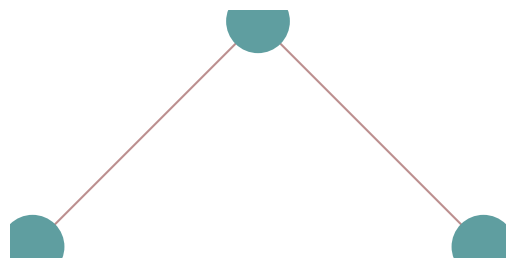

In [12]:
cnr.plot()

In [13]:
cnr.optimize()

/var/folders/c3/657p__892k72qxh6r8fdkqsh0000gn/T/ipykernel_639/2887266960.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  cnr.optimize()
Index(['gas_plant_bus', 'coal_plant_bus', 'load_bus'], dtype='object', name='name')
Index(['gas_line', 'coal_line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 15 primals, 39 duals
Objective: 5.20e+03
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lowe

Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-y9trxx1n has 39 rows; 15 cols; 51 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [2e+00, 4e+00]
  Bound   [0e+00, 0e+00]
  RHS     [2e+02, 1e+03]
Presolving model
1 rows, 3 cols, 3 nonzeros  0s
Dependent equations search running on 1 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
1 rows, 3 cols, 3 nonzeros  0s
Presolve reductions: rows 1(-38); columns 3(-12); nonzeros 3(-48) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
          1     5.2000000000e+03 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-y9trxx1n
Model status        : Optimal
Simplex   iterations: 1
Objective value     :  5.2000000000e+03
P-D o

('ok', 'optimal')

In [14]:
cnr.generators_t.p

name,coal plant,gas plant,solar plant
snapshot,,,
0,300.0,200.0,-0.0
1,200.0,-0.0,200.0
2,300.0,400.0,-0.0


In [15]:
cnr.buses_t.marginal_price

name,gas_plant_bus,coal_plant_bus,load_bus
snapshot,,,
0,4.0,4.0,4.0
1,3.0,3.0,3.0
2,4.0,4.0,4.0
